STEP 1: Reading CSV and Calculating Configurational Entropy
✓ Loaded 15000 data points from MoNbTaW.csv
✓ Calculated configurational entropy for all compositions

✓ Applied 5.0 eV cutoff filter
  Original data points: 15000
  After cutoff: 14983
  Removed: 17 outliers (0.11%)
✓ Saved filtered CSV with entropy: gnn_training_data_with_entropy.csv

STEP 2: Creating Visualization with Standard Deviation Bands
✓ Plot saved as 'entropy_barriers_stddev.png'

STATISTICS SUMMARY

Total dataset: 14983 data points
Entropy range: [0.0000, 1.3858] R

FORWARD BARRIER
Mean:  0.5474 eV
Std:   0.1865 eV
Range: [0.0000, 1.5007] eV

Data coverage:
  Within ±1σ: 68.80% (expected: 68.3%)
  Within ±2σ: 95.24% (expected: 95.4%)
  Within ±3σ: 99.63% (expected: 99.7%)

BACKWARD BARRIER
Mean:  0.5464 eV
Std:   0.1861 eV
Range: [0.0000, 1.4375] eV

Data coverage:
  Within ±1σ: 68.34% (expected: 68.3%)
  Within ±2σ: 95.65% (expected: 95.4%)
  Within ±3σ: 99.59% (expected: 99.7%)

COMPLETED SUCCESSFULLY
Output fil

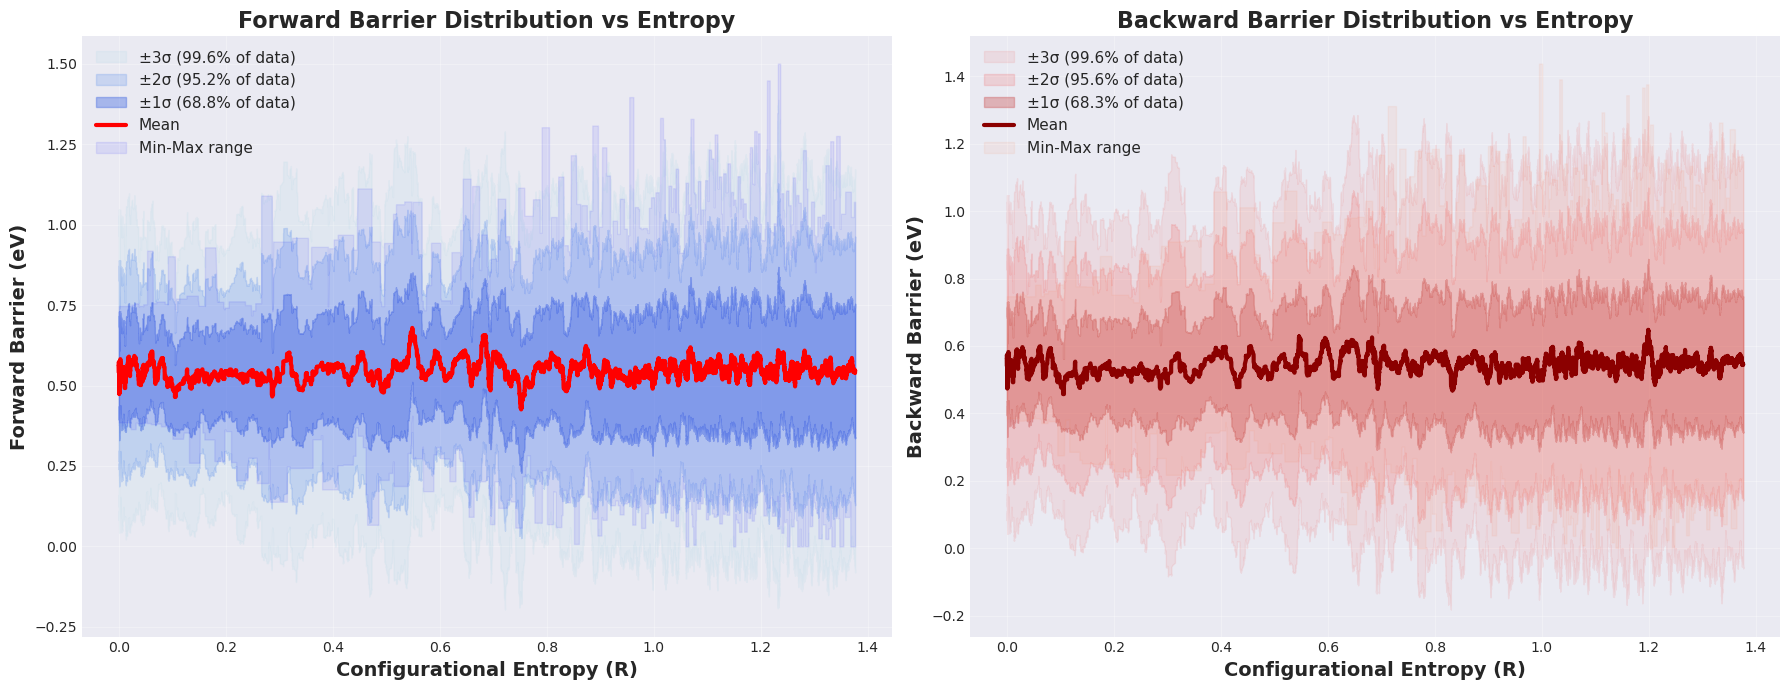

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("STEP 1: Reading CSV and Calculating Configurational Entropy")
print("="*60)

# Read the original CSV file
input_path = 'MoNbTaW.csv'
df = pd.read_csv(input_path)
print(f"✓ Loaded {len(df)} data points from {input_path}")

# Define function to calculate configurational entropy
def calculate_configurational_entropy(row):
    """
    Calculate configurational entropy using Boltzmann's equation:
    S_config = -k_B * sum(x_i * ln(x_i))
    
    Returns entropy in units of R (ideal gas constant)
    """
    # Extract atomic fractions
    fractions = [row['Mo'], row['Nb'], row['Ta'], row['W']]
    
    # Calculate entropy
    entropy = 0.0
    for x in fractions:
        if x > 0:  # Only include non-zero fractions (ln(0) is undefined)
            entropy -= x * np.log(x)
    
    return entropy

# Add configurational entropy column if not present
if 'configurational_entropy_R' not in df.columns:
    df['configurational_entropy_R'] = df.apply(calculate_configurational_entropy, axis=1)
    print(f"✓ Calculated configurational entropy for all compositions")
else:
    print(f"✓ Using existing configurational entropy column")

# Apply 5 eV cutoff filter
cutoff = 5.0
df_original_count = len(df)
df = df[(df['forward_barrier_eV'] <= cutoff) & (df['backward_barrier_eV'] <= cutoff)].copy()
print(f"\n✓ Applied {cutoff} eV cutoff filter")
print(f"  Original data points: {df_original_count}")
print(f"  After cutoff: {len(df)}")
print(f"  Removed: {df_original_count - len(df)} outliers ({100*(df_original_count - len(df))/df_original_count:.2f}%)")

# Save the modified dataframe
output_csv_path = 'gnn_training_data_with_entropy.csv'
df.to_csv(output_csv_path, index=False)
print(f"✓ Saved filtered CSV with entropy: {output_csv_path}")

print("\n" + "="*60)
print("STEP 2: Creating Visualization with Standard Deviation Bands")
print("="*60)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Sort data by entropy
df_sorted = df.sort_values('configurational_entropy_R')

# Rolling window size for smoothing
window = 100

# Function to calculate percentage of data within sigma bands
def calculate_sigma_coverage(data, mean, std, sigma):
    """Calculate percentage of data within ±sigma of mean"""
    within_band = np.abs(data - mean) <= sigma * std
    return 100 * np.sum(within_band) / len(data)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ========== Plot 1: Forward Barrier ==========
ax1 = axes[0]

# Calculate rolling statistics
rolling_mean_forward = df_sorted['forward_barrier_eV'].rolling(window=window, center=True).mean()
rolling_std_forward = df_sorted['forward_barrier_eV'].rolling(window=window, center=True).std()
rolling_min_forward = df_sorted['forward_barrier_eV'].rolling(window=window, center=True).min()
rolling_max_forward = df_sorted['forward_barrier_eV'].rolling(window=window, center=True).max()

# Calculate actual coverage percentages
coverage_1sigma_forward = calculate_sigma_coverage(
    df['forward_barrier_eV'].values,
    df['forward_barrier_eV'].mean(),
    df['forward_barrier_eV'].std(),
    1
)
coverage_2sigma_forward = calculate_sigma_coverage(
    df['forward_barrier_eV'].values,
    df['forward_barrier_eV'].mean(),
    df['forward_barrier_eV'].std(),
    2
)
coverage_3sigma_forward = calculate_sigma_coverage(
    df['forward_barrier_eV'].values,
    df['forward_barrier_eV'].mean(),
    df['forward_barrier_eV'].std(),
    3
)

# Plot ±3σ band (lightest)
ax1.fill_between(df_sorted['configurational_entropy_R'],
                rolling_mean_forward - 3*rolling_std_forward,
                rolling_mean_forward + 3*rolling_std_forward,
                alpha=0.15, color='lightblue', 
                label=f'±3σ ({coverage_3sigma_forward:.1f}% of data)')

# Plot ±2σ band
ax1.fill_between(df_sorted['configurational_entropy_R'],
                rolling_mean_forward - 2*rolling_std_forward,
                rolling_mean_forward + 2*rolling_std_forward,
                alpha=0.25, color='cornflowerblue', 
                label=f'±2σ ({coverage_2sigma_forward:.1f}% of data)')

# Plot ±1σ band (darkest)
ax1.fill_between(df_sorted['configurational_entropy_R'],
                rolling_mean_forward - rolling_std_forward,
                rolling_mean_forward + rolling_std_forward,
                alpha=0.4, color='royalblue', 
                label=f'±1σ ({coverage_1sigma_forward:.1f}% of data)')

# Mean line
ax1.plot(df_sorted['configurational_entropy_R'], rolling_mean_forward, 
        'red', linewidth=3, label='Mean', zorder=10)

# Min-Max envelope (very light)
ax1.fill_between(df_sorted['configurational_entropy_R'],
                rolling_min_forward, rolling_max_forward,
                alpha=0.08, color='blue', label='Min-Max range')

ax1.set_xlabel('Configurational Entropy (R)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Forward Barrier (eV)', fontsize=14, fontweight='bold')
ax1.set_title('Forward Barrier Distribution vs Entropy', fontsize=16, fontweight='bold')
ax1.legend(loc='best', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# ========== Plot 2: Backward Barrier ==========
ax2 = axes[1]

# Calculate rolling statistics
rolling_mean_backward = df_sorted['backward_barrier_eV'].rolling(window=window, center=True).mean()
rolling_std_backward = df_sorted['backward_barrier_eV'].rolling(window=window, center=True).std()
rolling_min_backward = df_sorted['backward_barrier_eV'].rolling(window=window, center=True).min()
rolling_max_backward = df_sorted['backward_barrier_eV'].rolling(window=window, center=True).max()

# Calculate actual coverage percentages
coverage_1sigma_backward = calculate_sigma_coverage(
    df['backward_barrier_eV'].values,
    df['backward_barrier_eV'].mean(),
    df['backward_barrier_eV'].std(),
    1
)
coverage_2sigma_backward = calculate_sigma_coverage(
    df['backward_barrier_eV'].values,
    df['backward_barrier_eV'].mean(),
    df['backward_barrier_eV'].std(),
    2
)
coverage_3sigma_backward = calculate_sigma_coverage(
    df['backward_barrier_eV'].values,
    df['backward_barrier_eV'].mean(),
    df['backward_barrier_eV'].std(),
    3
)

# Plot ±3σ band (lightest)
ax2.fill_between(df_sorted['configurational_entropy_R'],
                rolling_mean_backward - 3*rolling_std_backward,
                rolling_mean_backward + 3*rolling_std_backward,
                alpha=0.15, color='lightcoral', 
                label=f'±3σ ({coverage_3sigma_backward:.1f}% of data)')

# Plot ±2σ band
ax2.fill_between(df_sorted['configurational_entropy_R'],
                rolling_mean_backward - 2*rolling_std_backward,
                rolling_mean_backward + 2*rolling_std_backward,
                alpha=0.25, color='lightcoral', 
                label=f'±2σ ({coverage_2sigma_backward:.1f}% of data)')

# Plot ±1σ band (darkest)
ax2.fill_between(df_sorted['configurational_entropy_R'],
                rolling_mean_backward - rolling_std_backward,
                rolling_mean_backward + rolling_std_backward,
                alpha=0.4, color='indianred', 
                label=f'±1σ ({coverage_1sigma_backward:.1f}% of data)')

# Mean line
ax2.plot(df_sorted['configurational_entropy_R'], rolling_mean_backward, 
        'darkred', linewidth=3, label='Mean', zorder=10)

# Min-Max envelope (very light)
ax2.fill_between(df_sorted['configurational_entropy_R'],
                rolling_min_backward, rolling_max_backward,
                alpha=0.08, color='coral', label='Min-Max range')

ax2.set_xlabel('Configurational Entropy (R)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Backward Barrier (eV)', fontsize=14, fontweight='bold')
ax2.set_title('Backward Barrier Distribution vs Entropy', fontsize=16, fontweight='bold')
ax2.legend(loc='best', fontsize=11, framealpha=0.9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
output_plot_path = 'entropy_barriers_stddev.png'
plt.savefig(output_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Plot saved as '{output_plot_path}'")

# Print detailed statistics
print("\n" + "="*60)
print("STATISTICS SUMMARY")
print("="*60)
print(f"\nTotal dataset: {len(df)} data points")
print(f"Entropy range: [{df['configurational_entropy_R'].min():.4f}, {df['configurational_entropy_R'].max():.4f}] R")

print(f"\n{'='*60}")
print("FORWARD BARRIER")
print(f"{'='*60}")
print(f"Mean:  {df['forward_barrier_eV'].mean():.4f} eV")
print(f"Std:   {df['forward_barrier_eV'].std():.4f} eV")
print(f"Range: [{df['forward_barrier_eV'].min():.4f}, {df['forward_barrier_eV'].max():.4f}] eV")
print(f"\nData coverage:")
print(f"  Within ±1σ: {coverage_1sigma_forward:.2f}% (expected: 68.3%)")
print(f"  Within ±2σ: {coverage_2sigma_forward:.2f}% (expected: 95.4%)")
print(f"  Within ±3σ: {coverage_3sigma_forward:.2f}% (expected: 99.7%)")

print(f"\n{'='*60}")
print("BACKWARD BARRIER")
print(f"{'='*60}")
print(f"Mean:  {df['backward_barrier_eV'].mean():.4f} eV")
print(f"Std:   {df['backward_barrier_eV'].std():.4f} eV")
print(f"Range: [{df['backward_barrier_eV'].min():.4f}, {df['backward_barrier_eV'].max():.4f}] eV")
print(f"\nData coverage:")
print(f"  Within ±1σ: {coverage_1sigma_backward:.2f}% (expected: 68.3%)")
print(f"  Within ±2σ: {coverage_2sigma_backward:.2f}% (expected: 95.4%)")
print(f"  Within ±3σ: {coverage_3sigma_backward:.2f}% (expected: 99.7%)")

print("\n" + "="*60)
print("COMPLETED SUCCESSFULLY")
print("="*60)
print(f"Output files created:")
print(f"  1. {output_csv_path}")
print(f"  2. {output_plot_path}")

plt.show()